In [1]:
%pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.2
    Uninstalling protobuf-7.36.2:
      Successfully uninstalled protobuf-7.36.2
Note: you may need to restart the kernel to use updated packages.


In [1]:
import streamlit as st

print("Streamlit version:", st.__version__)

Streamlit version: 1.51.0


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
import tensorflow as tf

MODEL_PATH = r"C:\Users\vigne\Hackathon - 404 Impact\plant_disease_model.keras"

loaded_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully.")
print("Input shape:", loaded_model.input_shape)
print("Output shape:", loaded_model.output_shape)

Model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 38)


In [4]:
print("Number of classes:", len(class_names))
print("Class names:")
for i, name in enumerate(class_names):
    print(i, "→", name)

NameError: name 'class_names' is not defined

In [5]:
class_names = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [7]:
IMG_SIZE = (224, 224)

print("Image size:", IMG_SIZE)

Image size: (224, 224)


In [8]:
import os
import tensorflow as tf
import numpy as np

folder = r"C:\Users\vigne\Downloads\PlantVillage\Val\Tomato___Early_blight"

image_id = "ca7035fa-f55d-49c7-9d89-3d513c8e35b1___RS_Erly.B 7556"

matches = [
    f for f in os.listdir(folder)
    if image_id in f
]

if len(matches) == 0:
    print("Image not found.")

else:
    image_path = os.path.join(folder, matches[0])

    print("Exact image being tested:")
    print(image_path)

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    predictions = loaded_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print("\nPrediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

Exact image being tested:
C:\Users\vigne\Downloads\PlantVillage\Val\Tomato___Early_blight\ca7035fa-f55d-49c7-9d89-3d513c8e35b1___RS_Erly.B 7556.JPG

Prediction: Tomato___Early_blight
Confidence: 50.64%


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

C:\Users\vigne\AppData\Local\Temp\ipykernel_23200\2970565935.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


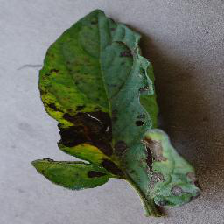

In [10]:
from IPython.display import display

display(image)

In [12]:
def predict_image(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    predictions = loaded_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    return predicted_class, confidence

In [13]:
predicted_class, confidence = predict_image(image_path)

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Prediction: Tomato___Early_blight
Confidence: 50.64%


In [14]:
from PIL import Image

uploaded_test_image = Image.open(image_path)

print("Image loaded successfully.")
print("Image size:", uploaded_test_image.size)
print("Image mode:", uploaded_test_image.mode)

Image loaded successfully.
Image size: (256, 256)
Image mode: RGB


In [15]:
def predict_uploaded_image(uploaded_image):

    image = uploaded_image.convert("RGB")
    image = image.resize(IMG_SIZE)

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    predictions = loaded_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    return predicted_class, confidence

In [16]:
predicted_class, confidence = predict_uploaded_image(
    uploaded_test_image
)

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Prediction: Tomato___Bacterial_spot
Confidence: 63.30%


In [17]:
print("Original image size:", image.size)

processed_uploaded = uploaded_test_image.resize(IMG_SIZE)

print("Uploaded processed size:", processed_uploaded.size)

Original image size: (224, 224)
Uploaded processed size: (224, 224)


In [18]:
import numpy as np

original_array = np.array(image)
uploaded_array = np.array(processed_uploaded)

print("Same shape:", original_array.shape == uploaded_array.shape)
print("Exactly identical:", np.array_equal(original_array, uploaded_array))
print("Maximum pixel difference:",
      np.max(np.abs(original_array.astype(int) - uploaded_array.astype(int))))

Same shape: True
Exactly identical: False
Maximum pixel difference: 96


In [19]:
uploaded_test_image_path = image_path

streamlit_style_image = tf.keras.utils.load_img(
    uploaded_test_image_path,
    target_size=IMG_SIZE
)

streamlit_style_array = tf.keras.utils.img_to_array(
    streamlit_style_image
)

streamlit_style_array = np.expand_dims(
    streamlit_style_array,
    axis=0
)

predictions = loaded_model.predict(
    streamlit_style_array,
    verbose=0
)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Prediction: Tomato___Early_blight
Confidence: 50.64%


In [20]:
def predict_uploaded_image(uploaded_file):
    image = tf.keras.utils.load_img(
        uploaded_file,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    predictions = loaded_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    return image, predicted_class, confidence

In [21]:
image, predicted_class, confidence = predict_uploaded_image(
    image_path
)

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Prediction: Tomato___Early_blight
Confidence: 50.64%


In [22]:
from io import BytesIO

with open(image_path, "rb") as f:
    test_uploaded_file = BytesIO(f.read())

image, predicted_class, confidence = predict_uploaded_image(
    test_uploaded_file
)

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Prediction: Tomato___Early_blight
Confidence: 50.64%


In [23]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe
